In [24]:
import os, copy
import glob
from tqdm.auto import tqdm

import numpy as np
import scipy.optimize as so
import pandas as pd
import xarray as xr
import rioxarray as rxr
import datetime as dt
import cartopy.crs as ccrs

import netCDF4
import h5py
from osgeo import gdal

#%matplotlib widget
import matplotlib as mpl
import matplotlib.pyplot as plt
import colorcet as cc


import hgrs
import hgrs.driverEnMAP as driverEnMAP
import radcalnet_oc as radoc

opj = os.path.join
hgrs.__version__

'1.0.6'

### Set PRISMA file paths
Give path for L1C (L2C is normally in the same directory). The L2C is needed to get the viewing geometry parameters (viewing zenith angle, sun zenith angle and relative azimuth)


In [25]:
l1c_path ='/data/satellite/enmap/l1c/ENMAP01-____L1C-DT0000112067_20250124T160300Z_002_V010502_20250508T165054Z'#ENMAP01-____L1C-DT0000086069_20240723T111414Z_008_V010502_20250417T115758Z'
l1c_path ='/data/satellite/enmap/EnMAP_L1C/AAOT/ENMAP01-____L1C-DT0000001199_20220623T104344Z_015_V010502_20250308T051735Z'
cams_dir = '/data/cams/world/'
odir = '/data/satellite/enmap/l2a/loire'
basename = os.path.basename(l1c_path)
l2a_path = opj(odir,basename.replace('L1C','L2A')+'.nc')
l2a_path



'/data/satellite/enmap/l2a/loire/ENMAP01-____L2A-DT0000001199_20220623T104344Z_015_V010502_20250308T051735Z.nc'

In [26]:
driver = hgrs.Driver('enmap')
pbar = tqdm(total=1,
                    desc="loading image data")
l1c_prod = driver.driver(l1c_path,reflectance_unit=True)
algo = hgrs.Algo(l1c_prod, expon=1.5, xcoarsen=20, ycoarsen=20)
pbar.update()

date_str = str(l1c_prod.time.dt.strftime('%Y-%m').values)
cams_path = opj(cams_dir,f'cams_forecast_{date_str}.nc')
l1c_prod

loading image data:   0%|          | 0/1 [00:00<?, ?it/s]

<xarray.Dataset> Size: 6GB
Dimensions:      (wl: 224, x: 1263, y: 1232)
Coordinates:
  * wl           (wl) float64 2kB 418.2 423.8 429.3 ... 2.438e+03 2.446e+03
  * x            (x) float64 10kB 2.764e+05 2.764e+05 ... 3.142e+05 3.142e+05
  * y            (y) float64 10kB 5.052e+06 5.052e+06 ... 5.015e+06 5.015e+06
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2022-06-23T10:42:42.038673
Data variables:
    Ltoa         (wl, y, x) float64 3GB dask.array<chunksize=(20, 512, 512), meta=np.ndarray>
    F0           (wl) float64 2kB 1.779e+03 1.721e+03 1.637e+03 ... 56.43 55.56
    fwhm         (wl) float64 2kB 6.996 6.668 6.424 6.251 ... 7.224 7.192 7.158
    sza          (y, x) float64 12MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    saa          (y, x) float64 12MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    vza          (y, x) float64 12MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    vaa          (y, x) float64 12MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    raa          (y, x) float64 12MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    Rtoa         (wl, y, x) float64 3GB dask.array<chunksize=(20, 512, 512), meta=np.ndarray>
Attributes:
    description:       EnMAP L1C cube data
    L1C_product_name:  ENMAP01-____L1C-DT0000001199_20220623T104344Z_015_V010...
    acquisition_date:  2022-06-23 10:42:42.038673

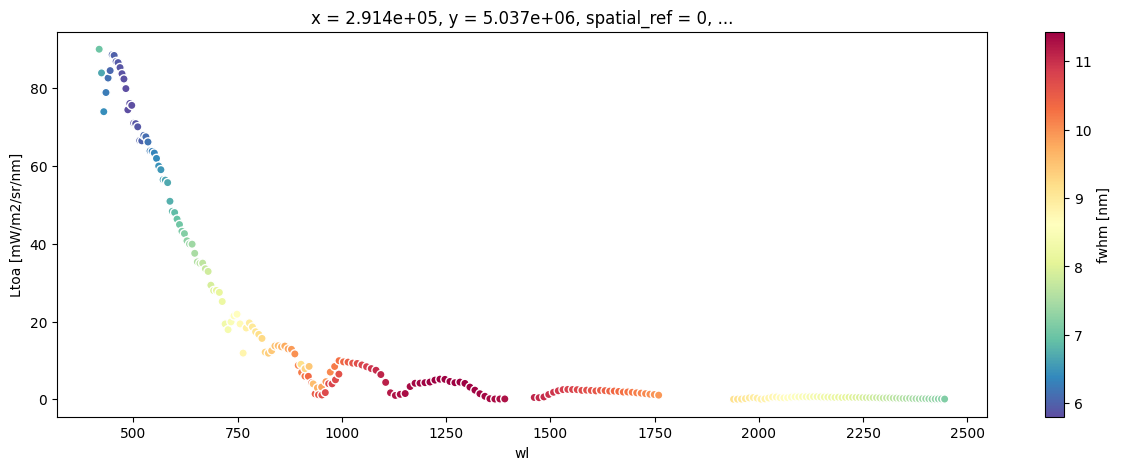

In [27]:
plt.figure(figsize=(15,5))
l1c_prod.isel(x=500,y=500).plot.scatter(y='Ltoa',x='wl',hue='fwhm',marker='o',cmap=plt.cm.Spectral_r)

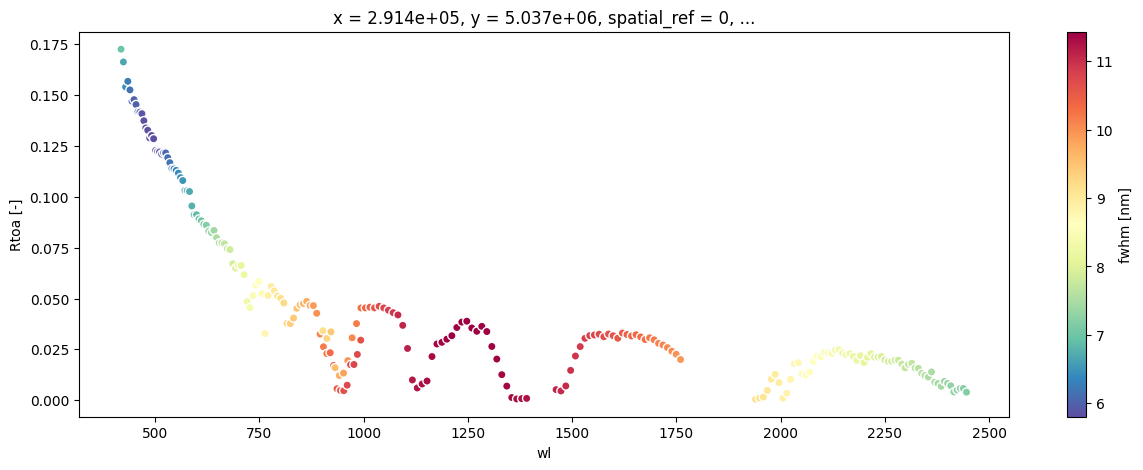

In [28]:
plt.figure(figsize=(15,5))
l1c_prod.isel(x=500,y=500).plot.scatter(y='Rtoa',x='wl',hue='fwhm',marker='o',cmap=plt.cm.Spectral_r)

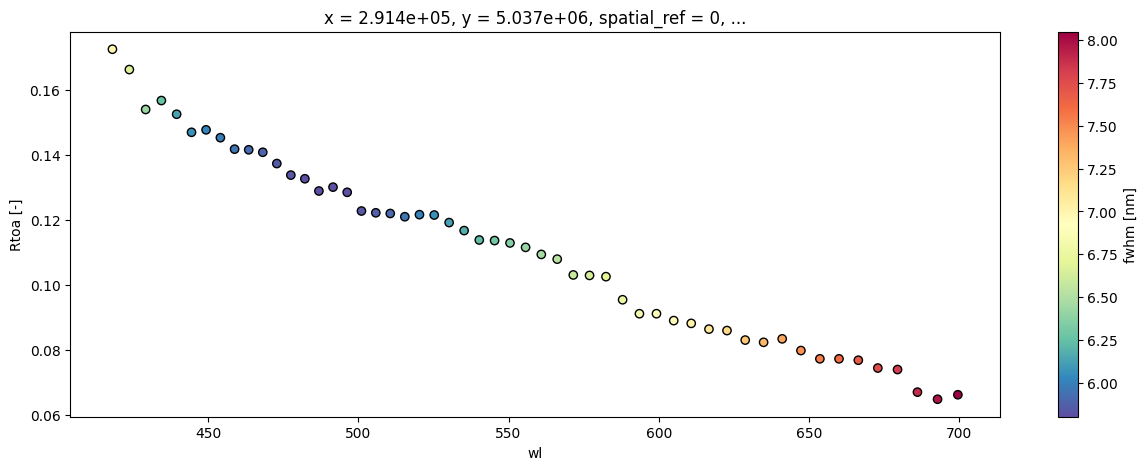

In [29]:
wl_range=slice(400,700)
plt.figure(figsize=(15,5))
l1c_prod.isel(x=500,y=500).sel(wl=wl_range).plot.scatter(y='Rtoa',x='wl',hue='fwhm',marker='o',edgecolor='k',cmap=plt.cm.Spectral_r)

In [30]:
lines_info[0][0]

430.774

/tmp/ipykernel_2779839/3997280196.py:57: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
/tmp/ipykernel_2779839/3997280196.py:66: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


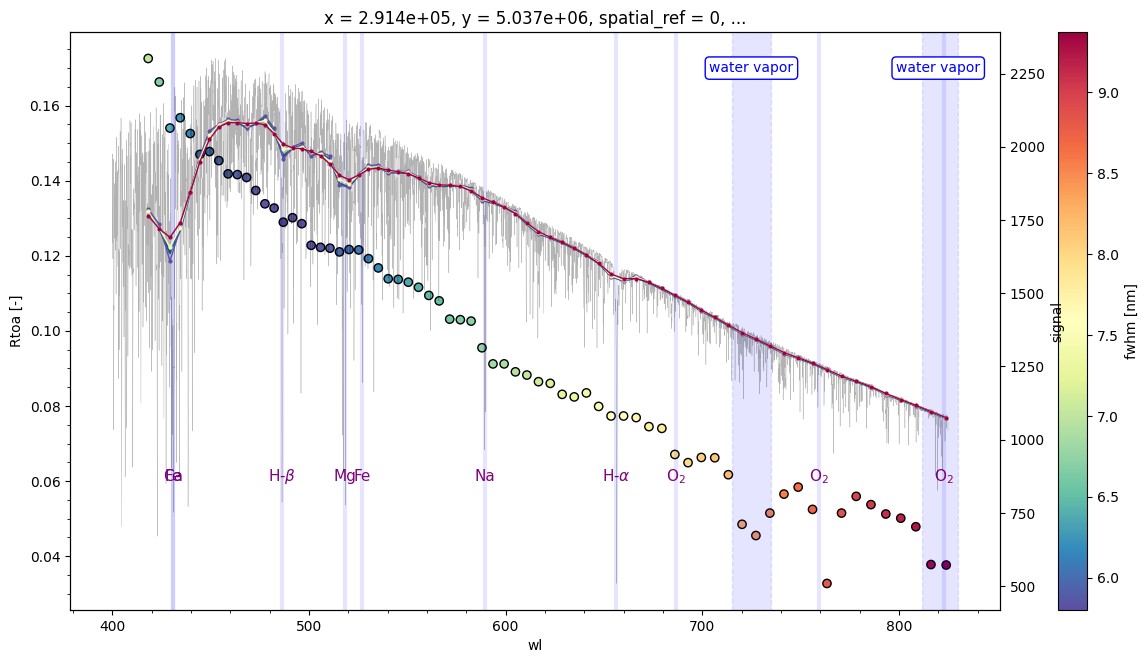

In [48]:
wl_range=slice(400,825)
fig,axs = plt.subplots(1,1,figsize=(15,7.5))#,sharey=True)   
fig.subplots_adjust(hspace=0.05, wspace=0.25)
ax=axs
axs=[axs]
Rtoa = l1c_prod.isel(x=500,y=500).sel(wl=wl_range)
Rtoa.plot.scatter(y='Rtoa',x='wl',hue='fwhm',marker='o',edgecolor='k',cmap=plt.cm.Spectral_r)
# Coordinates of absorption bands
lines_info = [
    (430.774, 'Ca'),
    (430.790, 'Fe'),
    (486.134, r'H-$\beta$'),
    (518.362, 'Mg'),
     (527.039, 'Fe'),
    (589.592, 'Na'),
   # (589.995, 'Na'),
    (656.281, r'H-$\alpha$'),
    (686.719, r'O$_2$'),
    (759.370, r'O$_2$'),
    (822.696, r'O$_2$')
]


# Sort and group
lines_info.sort(key=lambda x: x[0])

delta_nm = 0.5  # group threshold (where two bands or more are really close)
groups = []
current_group = [lines_info[0]]
for x, label in lines_info[1:]:
    if abs(x - current_group[-1][0]) <= delta_nm:
        current_group.append((x, label))
    else:
        groups.append(current_group)
        current_group = [(x, label)]
groups.append(current_group)


wl=Rtoa.wl
# Loop on both axis
for info in lines_info:
    x,label_text = info   
    # Annotation
    ax.text(
        x,0.06,label_text,
       
        
        ha='center',
       
        fontsize=11,
        color='purple'
    )
    #ax.axvspan(x*.99,x*1.01,alpha=0.1)
    ax.axvline(x,lw=3,alpha=0.1,color='b')
for ax in axs:
    # Rectangles for absorbtion of water vapor
    ax.axvspan(
        715, 735,
        color='blue',
        alpha=0.1,
        edgecolor='blue',
        linestyle='--',
        lw=1
    )

    ax.axvspan(
        812, 830,
        color='blue',
        alpha=0.1,
        edgecolor='blue',
        linestyle='--',
        lw=1
    )
    # Legend "water vapor" in the middle of the rectangle
    y_min, y_max = ax.get_ylim()
    ax.text(
        725,
        y_max - 0.05 * (y_max - y_min),  #the text is just below the max of the figure
        'water vapor',
        ha='center',
        va='top',
        fontsize=10,
        color='blue',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3')
    )
    ax.text(
        820,
        y_max - 0.05 * (y_max - y_min),  #the text is just below the max of the figure
        'water vapor',
        ha='center',
        va='top',
        fontsize=10,
        color='blue',
        bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3')
    )


cmap=plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=Rtoa.fwhm.min(),vmax=Rtoa.fwhm.max())
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

ax2 = ax.twinx()
l1c_prod.F0.sel(wl=wl_range).plot(ax=ax2)

solar_irr=radoc.SolarIrradiance()
spectral_res=1
central_wl=Rtoa.wl #np.arange(350,2500,spectral_res)

signal = solar_irr.tsis
wl_signal = solar_irr.tsis.wl.values

signal.sel(wl=wl_range).plot(lw=0.3,alpha=0.3,color='k',ax=ax2)
for fwhm in [5,7.5,10]:    
    spectral=radoc.Spectral(central_wl,fwhm)
    F0 = spectral.convolve(signal)*1.01
    F0.sel(wl=wl_range).plot(lw=1,marker='o',ms=2,color=cmap(norm(fwhm)),label='FWHM='+str(fwhm)+'nm',ax=ax2)
ax.minorticks_on()   


In [ ]:
ax.axvline

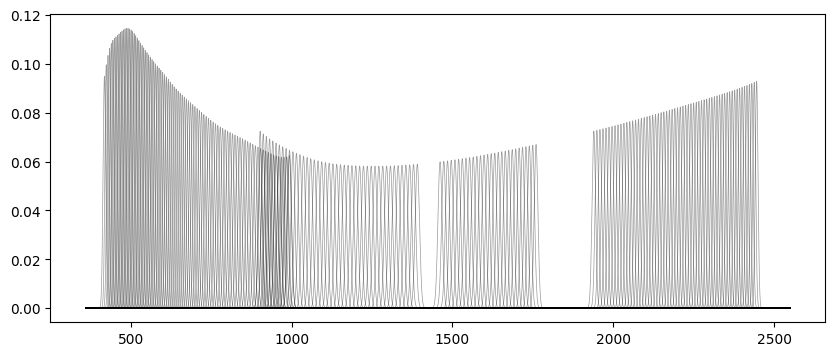

In [9]:
def Gamma2sigma(Gamma):
    '''Function to convert FWHM (Gamma) to standard deviation (sigma)'''
    return Gamma * np.sqrt(2.) / ( np.sqrt(2. * np.log(2.)) * 2. )

def gaussian(x,mu,sigma):
    return 1 / (sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))
    

wl_signal = np.linspace(360,2550,10000)
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
rho_int=[]
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):
    sig = Gamma2sigma(fwhm.values)
    rsr = gaussian(wl_signal,mu,sig)
    #rho_ = np.trapz(rho * rsr, wl_signal)/np.trapz(rsr, wl_signal)
    #rho_int.append(rho_)
    axs.plot(wl_signal,rsr,'-k',lw=0.5,alpha=0.4)

In [13]:
algo.gas_lut

<xarray.Dataset> Size: 2MB
Dimensions:  (wl: 21687)
Coordinates:
  * wl       (wl) float64 173kB 349.9 350.1 350.3 ... 2.599e+03 2.6e+03
Data variables:
    ch4      (wl) float64 173kB ...
    co       (wl) float64 173kB ...
    co2      (wl) float64 173kB ...
    h2o      (wl) float64 173kB ...
    n2o      (wl) float64 173kB ...
    no2      (wl) float64 173kB ...
    o2       (wl) float64 173kB ...
    o3       (wl) float64 173kB ...
    o4       (wl) float64 173kB ...
Attributes:
    description:           Absorption optical thickness of some atmospheric g...
    atmospheric pressure:  1000 hPa

In [17]:
rsr.where(rsr>1e-5,drop=True)

<xarray.DataArray 'wl' (wl: 61)> Size: 488B
array([1.36349550e-05, 2.40335891e-05, 4.15732305e-05, 7.06035899e-05,
       1.17667597e-04, 1.92520673e-04, 3.09160975e-04, 4.87358799e-04,
       7.53869449e-04, 1.14464955e-03, 1.70537101e-03, 2.49383333e-03,
       3.57929978e-03, 5.04046848e-03, 6.96534309e-03, 9.44615657e-03,
       1.25701099e-02, 1.64128540e-02, 2.10271306e-02, 2.64335687e-02,
       3.26028090e-02, 3.94489548e-02, 4.68332982e-02, 5.45496866e-02,
       6.23280662e-02, 6.98659998e-02, 7.68224719e-02, 8.28655896e-02,
       8.76805335e-02, 9.10007233e-02, 9.26407604e-02, 9.25035421e-02,
       9.05946994e-02, 8.70209082e-02, 8.19781789e-02, 7.57421394e-02,
       6.86282839e-02, 6.09813571e-02, 5.31384540e-02, 4.54045015e-02,
       3.80462844e-02, 3.12590809e-02, 2.51831416e-02, 1.98931171e-02,
       1.54062907e-02, 1.16997203e-02, 8.71018492e-03, 6.35755439e-03,
       4.54876137e-03, 3.19112152e-03, 2.19435175e-03, 1.47921559e-03,
       9.77482304e-04, 6.33180917e-04, 4.01973220e-04, 2.50187310e-04,
       1.52600307e-04, 9.12109563e-05, 5.34453177e-05, 3.06863751e-05,
       1.72677951e-05])
Coordinates:
  * wl       (wl) float64 488B 2.427e+03 2.428e+03 ... 2.463e+03 2.463e+03

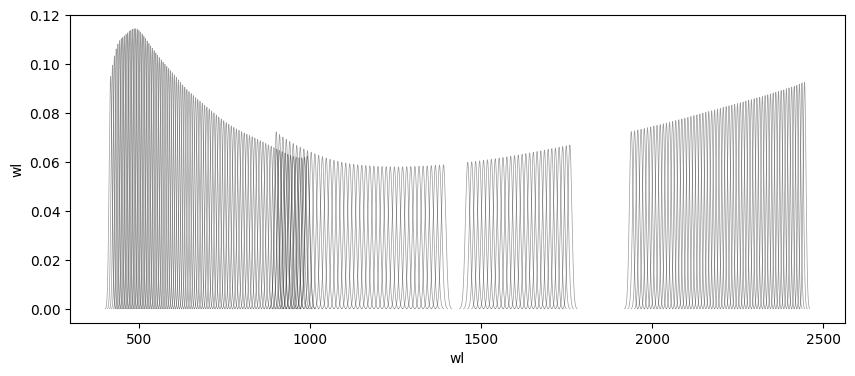

In [50]:
def Gamma2sigma(Gamma):
    '''Function to convert FWHM (Gamma) to standard deviation (sigma)'''
    return Gamma * np.sqrt(2.) / ( np.sqrt(2. * np.log(2.)) * 2. )

def gaussian(x,mu,sigma):
    return 1 / (sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))
    

wl_signal = algo.gas_lut.wl
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
RSR={}
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):
    sig = Gamma2sigma(fwhm.values)
    rsr = gaussian(wl_signal,mu,sig)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr
    #rho_ = np.trapz(rho * rsr, wl_signal)/np.trapz(rsr, wl_signal)
    #rho_int.append(rho_)
    rsr.plot(color='k',ax=axs,lw=0.5,alpha=0.4)

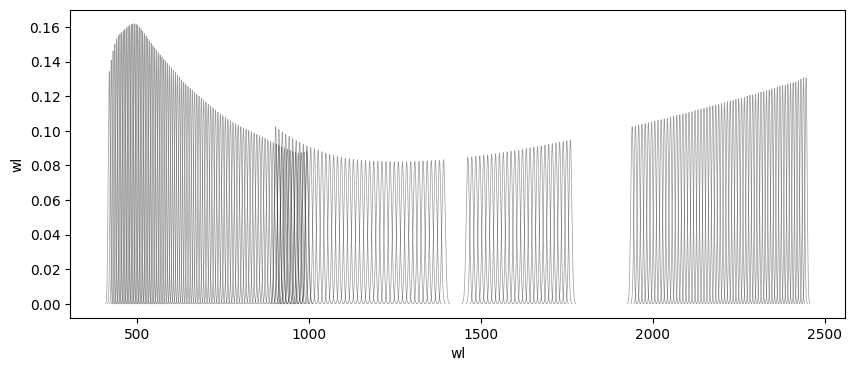

In [51]:
def Gamma2sigma(Gamma):
    '''Function to convert FWHM (Gamma) to standard deviation (sigma)'''
    return Gamma * np.sqrt(2.) / ( np.sqrt(2. * np.log(2.)) * 2. )

def gaussian(x,mu,sigma):
    return 1 / (sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*sigma**2))
    
def super_gaussian(x,
                   amplitude=1.0,
                   mu=0.0,
                   sigma=1.0,
                   expon=10.0):
    '''
    Super-Gaussian distribution:
    super_gaussian(x, amplitude, mu, sigma, expon) =
        (amplitude/(sqrt(2*pi)*sigma)) * exp(-abs(x-mu)**expon / (2*sigma**expon))
    :param x:
    :param amplitude:
    :param mu:
    :param sigma:
    :param expon:
    :return:
    '''

    sigma = max(1.e-15, sigma)
    return amplitude / (np.sqrt(2 * np.pi) * sigma) * \
        np.exp(-np.abs(x - mu) ** expon / (2 * sigma ** expon))



def super_gaussian_fwhm2sigma(fwhm,
                              expon):
    '''
    Function to convert FWHM to standard deviation (sigma) of the super-gaussian distribution
    :param fwhm:
    :param expon:
    :return:
    '''
    return fwhm / 2 * (2 * np.log(2)) ** (-1 / expon)
    
expon=2
wl_signal = algo.gas_lut.wl
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
RSR={}
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):

    
    sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
    rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr
    #rho_ = np.trapz(rho * rsr, wl_signal)/np.trapz(rsr, wl_signal)
    #rho_int.append(rho_)
    rsr.plot(color='k',ax=axs,lw=0.5,alpha=0.4)

In [52]:
sig

array([3.03976519])

In [53]:
super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)

<xarray.DataArray 'wl' (wl: 21687)> Size: 173kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(21687,))
Coordinates:
  * wl       (wl) float64 173kB 349.9 350.1 350.3 ... 2.599e+03 2.6e+03

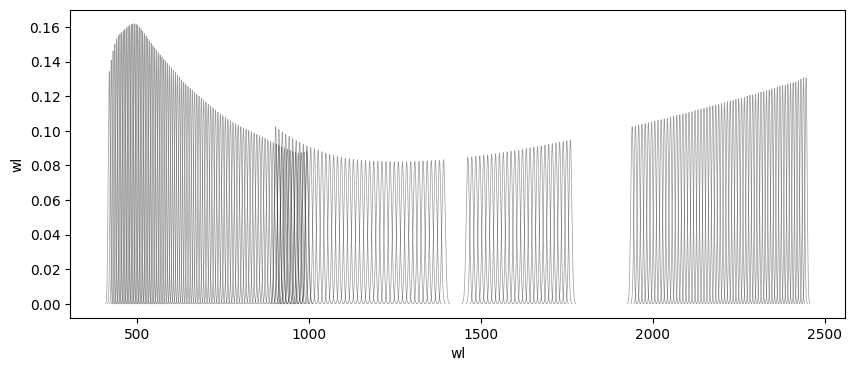

In [54]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))

for mu,fwhm in l1c_prod.fwhm.groupby('wl'):

    RSR[mu].plot(color='k',ax=axs,lw=0.5,alpha=0.4)

In [55]:
Twv_hyp = np.exp(- algo.air_mass_mean * algo.gas_lut.h2o*21)
Twv_hyp

<xarray.DataArray 'h2o' (wl: 21687)> Size: 173kB
array([1.00000000e+000, 1.00000000e+000, 1.00000000e+000, ...,
       1.74870379e-112, 7.95549882e-068, 3.24952094e-118], shape=(21687,))
Coordinates:
  * wl       (wl) float64 173kB 349.9 350.1 350.3 ... 2.599e+03 2.6e+03

In [56]:

@njit(parallel=True)
def convolve_(
        wl_signal,
        signal,
        wl,
        fwhm,
):
    '''
    Convolution assuming Dirac for signal source spectral response
    :paral wl_signal: wavelength array of spectral signal
    :param signal: numpy of signal to convolve, coord=wl_signal
    :param wl: numpy of wavelength coordinates of signal
    :param fwhm: numpy with data=fwhm containing full width at half maximum in nm
    :return: numpy of convoluted signal
    '''
    Nwl = len(wl)
    signal_ = np.full((Nwl), np.nan, dtype=np.float32)
    for ii in prange(len(fwhm)):
        sig = Gamma2sigma(fwhm[ii])
        rsr = gaussian(wl_signal, wl[ii], sig)
        signal_[ii] = np.trapezoid((signal * rsr), wl_signal) / np.trapezoid(rsr, wl_signal)
    return signal_


NameError: name 'njit' is not defined

In [57]:


Nwl = len(l1c_prod.wl)
signal_ = np.full((Nwl), np.nan, dtype=np.float32)
for ii, wl in enumerate(l1c_prod.wl.values):
    rsr = RSR[wl]
    signal = Twv_hyp.sel(wl=rsr.wl)
    signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)

In [59]:
signal

<xarray.DataArray 'SSI' (wl: 92001)> Size: 736kB
array([350.88425594, 293.6813706 , 277.97480311, ...,  43.72224572,
        43.72240557,  43.697479  ], shape=(92001,))
Coordinates:
  * wl       (wl) float64 736kB 300.0 300.0 300.1 ... 2.6e+03 2.6e+03 2.6e+03
Attributes:
    units:      mW m-2 nm-1
    long_name:  Solar Spectral Irradiance Reference Spectrum (mW m-2 nm-1)
    reference:  Coddington, O. M., Richard, E. C., Harber, D., et al. (2021)....

convolution:   0%|          | 0/5 [00:00<?, ?it/s]

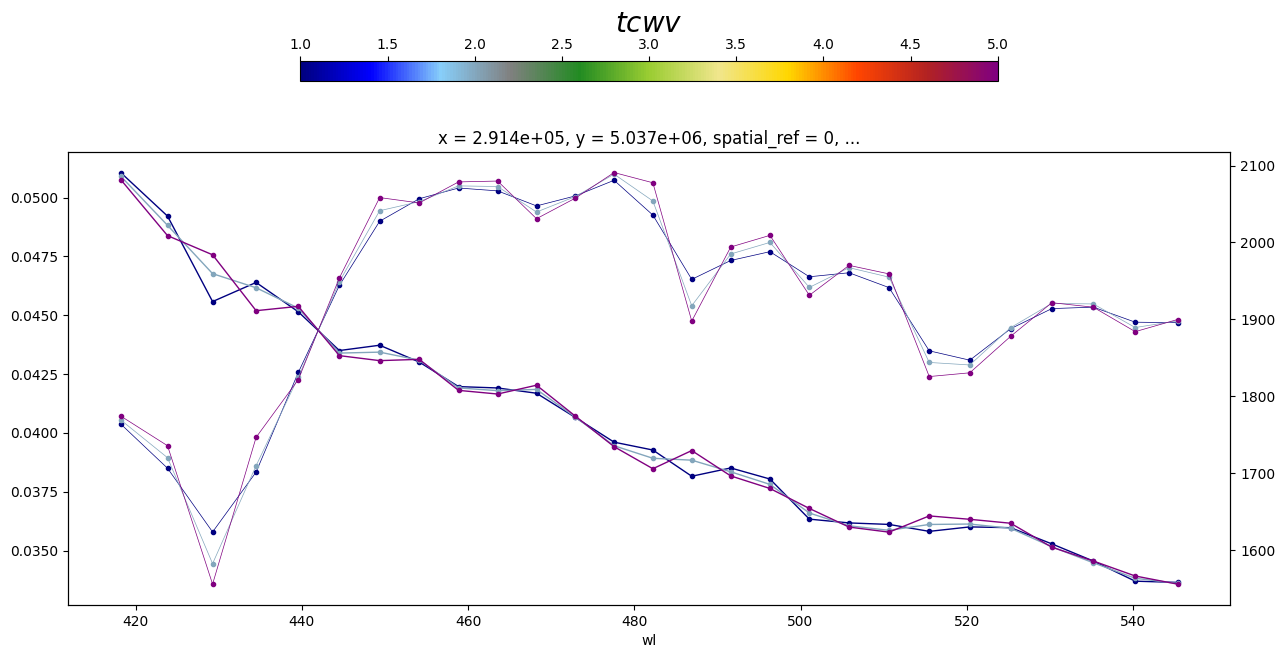

In [75]:



expon=2
wl_signal = algo.gas_lut.wl
wl_range = slice(400,550)
fwhms = l1c_prod.fwhm.sel(wl=wl_range)
Nwl = len(fwhms.wl)
signal_ = np.full((Nwl), np.nan, dtype=np.float32)
ot_wv = algo.gas_lut.h2o

cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=1.,vmax=5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

signal = solar_irr.tsis
wl_signal = solar_irr.tsis.wl#.values

Ltoa = l1c_prod.isel(x=500,y=500).Ltoa
fig,axs = plt.subplots(1,1,figsize=(15,8),sharey=True)
fig.subplots_adjust( hspace=0.25, wspace=0.3,)
pbar = tqdm(total=5, desc="convolution")
ax=axs#[ii]
ax2=ax.twinx()
for ii,expon in enumerate([1,2,5]):
    
    RSR={}
    for mu,fwhm in fwhms.groupby('wl'):
        if expon==1: 
            sig = Gamma2sigma(fwhm.values)
            rsr = gaussian(wl_signal,mu,sig)
        else:        
            sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
            rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
        rsr = rsr.where(rsr>1e-4,drop=True)
        RSR[mu]=rsr
    
    
    for ii, (wl, rsr) in  enumerate(RSR.items()):
      
        signal_wl = signal.sel(wl=slice(rsr.wl.values[0],rsr.wl.values[-1]))
        signal_[ii] = np.trapezoid((signal_wl * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
    xsignal = xr.DataArray(signal_,coords={'wl':fwhms.wl})
    
    xsignal.sel(wl=wl_range).plot(x='wl',color=cmap(norm(expon)),lw=0.5,marker='o',ms=3,ax=ax2)   
   # plt.plot(fwhms.wl,signal_)
    pbar.update()
    ax.set_title(f'Super Gaussian expon. {expon}')


    Rtoa=Ltoa/xsignal
    Rtoa.sel(wl=wl_range).plot(x='wl',color=cmap(norm(expon)),marker='o',lw=1,ms=3,ax=ax)   
cb = fig.colorbar(sm, ax=axs, shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$tcwv$', fontsize=20)

In [ ]:
Nwl = len(l1c_prod.wl)
signal_ = np.full((Nwl), np.nan, dtype=np.float32)

plt.figure(figsize=(15,5))
Twv_hyp.plot(lw=0.3,color='green', alpha=0.3)

RSR={}
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):
    sig = Gamma2sigma(fwhm.values)
    rsr = gaussian(wl_signal,mu,sig)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr
for ii, wl in enumerate(l1c_prod.wl.values):
    rsr = RSR[wl]
    signal = Twv_hyp.sel(wl=rsr.wl)
    signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
xsignal = xr.DataArray(signal_,coords={'wl':fwhms.wl}
xsignal.plot()

expon=2
wl_signal = algo.gas_lut.wl

RSR={}
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):

    
    sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
    rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr
for ii, wl in enumerate(l1c_prod.wl.values):
    rsr = RSR[wl]
    signal = Twv_hyp.sel(wl=rsr.wl)
    signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
plt.plot(l1c_prod.wl,signal_)

Twv convolution:   0%|          | 0/8 [00:00<?, ?it/s]

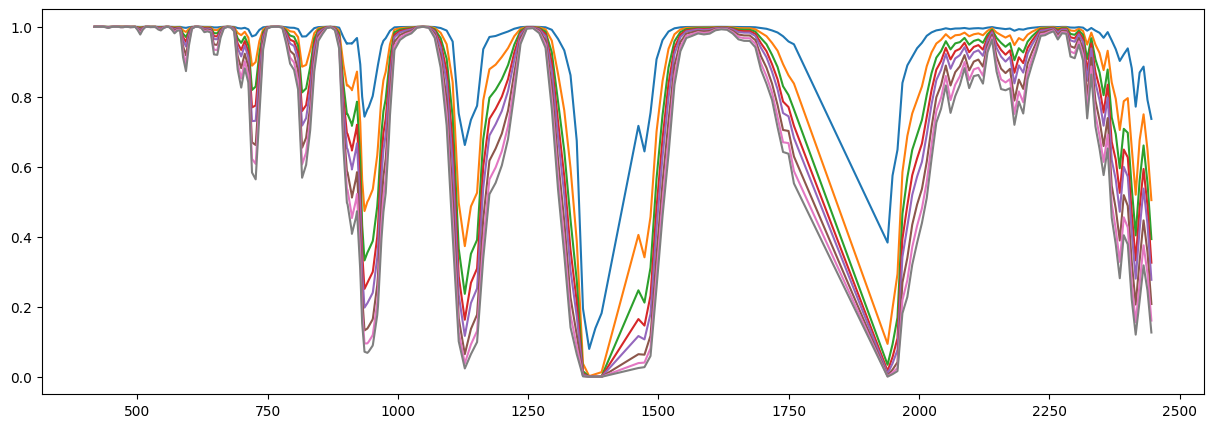

In [70]:
expon=2
wl_signal = algo.gas_lut.wl

RSR={}
for mu,fwhm in l1c_prod.fwhm.groupby('wl'):
    
    sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
    rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr

plt.figure(figsize=(15,5))
pbar = tqdm(total=8,
                    desc="Twv convolution")

for  tcwv in [1,5,10,15,20,30,40,50]:
    Twv_hyp = np.exp(- algo.air_mass_mean * algo.gas_lut.h2o*tcwv)
    for ii, (wl, rsr) in  enumerate(RSR.items()):
        
        signal = Twv_hyp.sel(wl=slice(rsr.wl.values[0],rsr.wl.values[-1]))
        signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
        
    plt.plot(l1c_prod.wl,signal_)
    pbar.update()

Twv convolution:   0%|          | 0/8 [00:00<?, ?it/s]

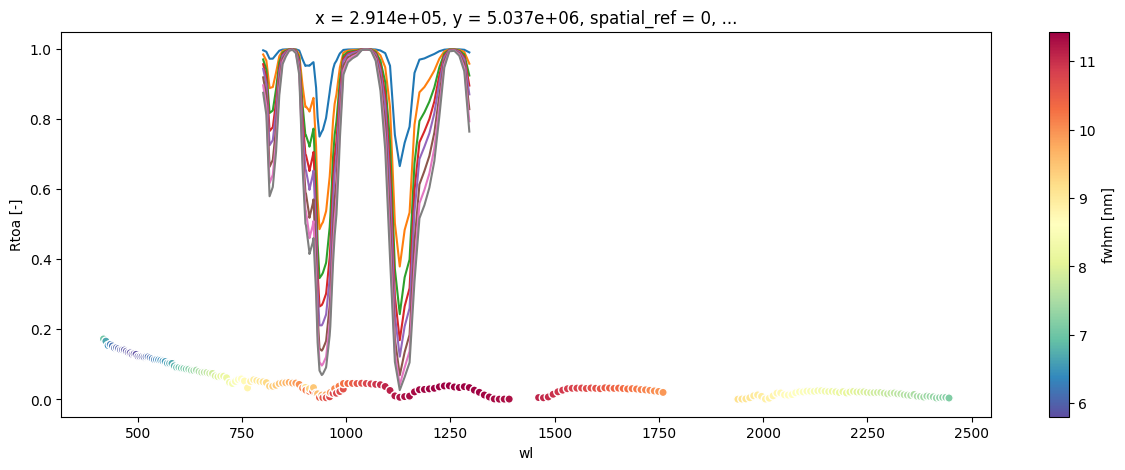

In [87]:
expon=1.7
wl_signal = algo.gas_lut.wl
fwhms = l1c_prod.fwhm.sel(wl=slice(800,1300))
Nwl = len(fwhms.wl)
signal_ = np.full((Nwl), np.nan, dtype=np.float32)



ot_wv = algo.gas_lut.h2o
RSR={}
for mu,fwhm in fwhms.groupby('wl'):

    
    sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
    rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
    rsr = rsr.where(rsr>1e-4,drop=True)
    RSR[mu]=rsr

plt.figure(figsize=(15,5))
pbar = tqdm(total=8,
                    desc="Twv convolution")



for  tcwv in [1,5,10,15,20,30,40,50]:
    Twv_hyp = np.exp(- algo.air_mass_mean * ot_wv*tcwv)
    for ii, (wl, rsr) in  enumerate(RSR.items()):
      
        signal = Twv_hyp.sel(wl=slice(rsr.wl.values[0],rsr.wl.values[-1]))
        signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
        
    plt.plot(fwhms.wl,signal_)
    pbar.update()


Twv convolution:   0%|          | 0/8 [00:00<?, ?it/s]

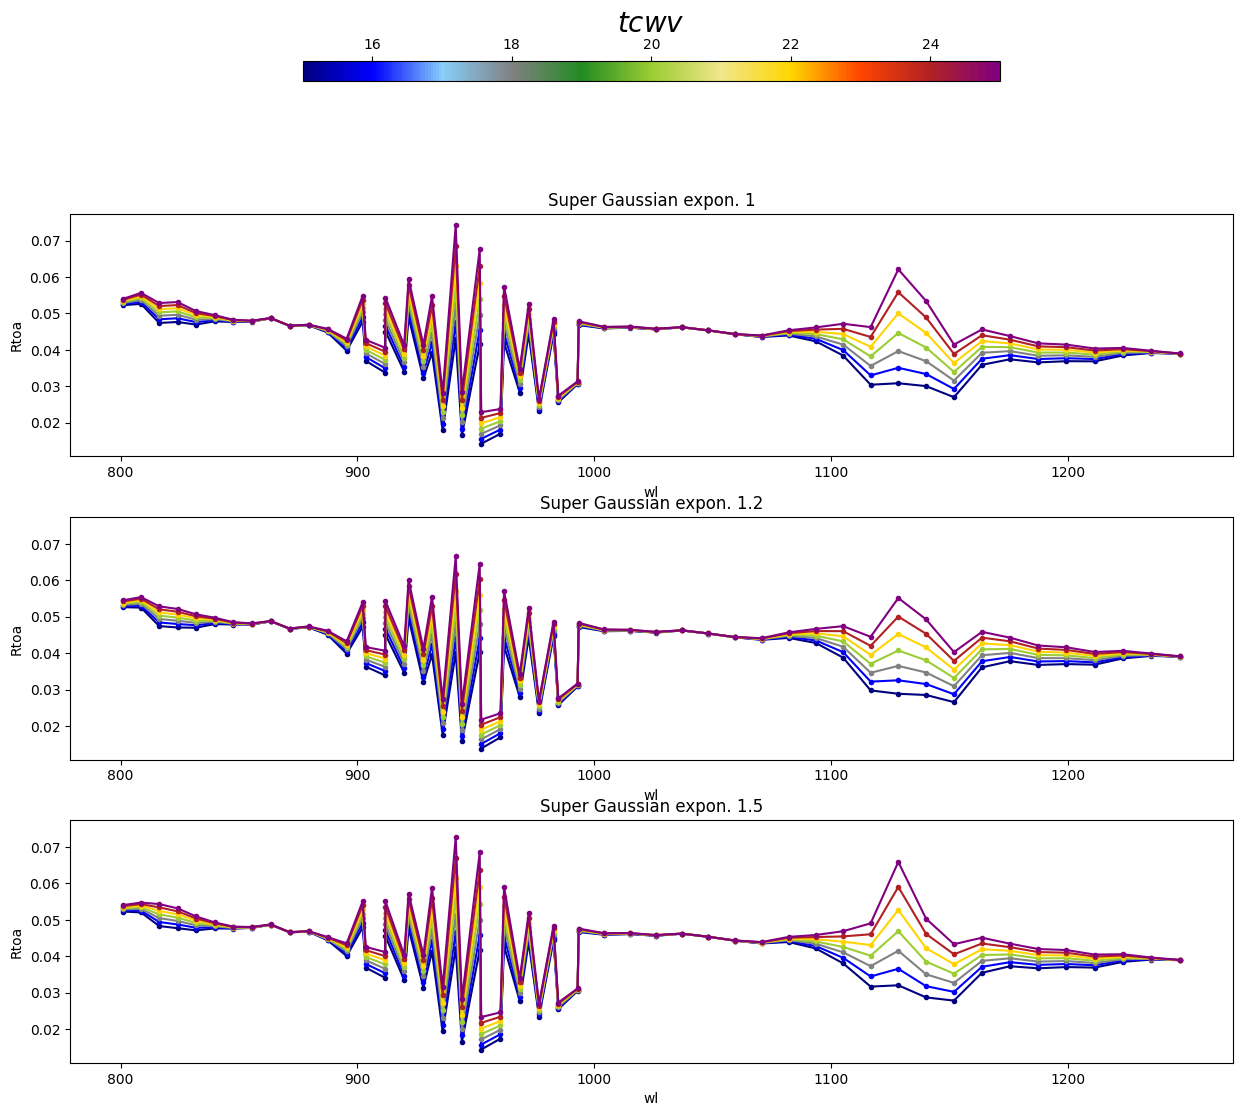

In [116]:
expon=2
wl_signal = algo.gas_lut.wl
wl_range = slice(800,1250)
fwhms = l1c_prod.fwhm.sel(wl=wl_range)
Nwl = len(fwhms.wl)
signal_ = np.full((Nwl), np.nan, dtype=np.float32)
ot_wv = algo.gas_lut.h2o

cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=15.,vmax=25)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])




fig,axs = plt.subplots(3,1,figsize=(15,15),sharey=True)
fig.subplots_adjust( hspace=0.25, wspace=0.3,)
pbar = tqdm(total=8,
                    desc="Twv convolution")
for ii,expon in enumerate([1,1.2,1.5]):
    ax=axs[ii]
    RSR={}
    for mu,fwhm in fwhms.groupby('wl'):
        if expon==1: 
            sig = Gamma2sigma(fwhm.values)
            rsr = gaussian(wl_signal,mu,sig)
        else:        
            sig = super_gaussian_fwhm2sigma(fwhm.values, expon)
            rsr = super_gaussian(wl_signal, mu=mu, sigma=sig, expon=expon)
        rsr = rsr.where(rsr>1e-4,drop=True)
        RSR[mu]=rsr
    
    for  tcwv in [14,16,18,20,22,24,26]:
        Twv_hyp = np.exp(- algo.air_mass_mean * ot_wv*tcwv)
        for ii, (wl, rsr) in  enumerate(RSR.items()):
          
            signal = Twv_hyp.sel(wl=slice(rsr.wl.values[0],rsr.wl.values[-1]))
            signal_[ii] = np.trapezoid((signal * rsr), rsr.wl) / np.trapezoid(rsr, rsr.wl)
        Twv_int = xr.DataArray(signal_,coords={'wl':fwhms.wl})
        (l1c_prod.isel(x=500,y=500).sel(wl=wl_range)/Twv_int).Rtoa.plot(x='wl',color=cmap(norm(tcwv)),marker='o',ms=3,ax=ax)   
       # plt.plot(fwhms.wl,signal_)
    pbar.update()
    ax.set_title(f'Super Gaussian expon. {expon}')
cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.115, location='top')
cb.set_label(r'$tcwv$', fontsize=20)

np.float64(786.503601)

In [78]:
Twv_hyp#.sel(wl=slice(rsr.wl.values[0],rsr.wl.values[-1]))

<xarray.DataArray 'h2o' (wl: 4808)> Size: 38kB
array([0.99206815, 0.99454537, 0.99827294, ..., 0.99575158, 0.97338786,
       0.9980751 ], shape=(4808,))
Coordinates:
  * wl       (wl) float64 38kB 800.0 800.1 800.2 ... 1.3e+03 1.3e+03 1.3e+03